In [1]:
from google.colab import drive
import os
drive.mount("/content/drive")
if not os.path.exists("/content/drive/MyDrive/Detection-of-Hateful-Memes-project"):
    os.makedirs("/content/drive/MyDrive/Detection-of-Hateful-Memes-project")
    !git clone https://github.com/soheil-housni/Detection-of-Hateful-Memes-project.git /content/drive/MyDrive/Detection-of-Hateful-Memes-project

else:
    %cd /content/drive/MyDrive/Detection-of-Hateful-Memes-project
    !git pull origin main

os.chdir("/content/drive/MyDrive/Detection-of-Hateful-Memes-project/RESNET_BERT_model")
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Detection-of-Hateful-Memes-project
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 7 (delta 5), reused 7 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 1.20 KiB | 0 bytes/s, done.
From https://github.com/soheil-housni/Detection-of-Hateful-Memes-project
 * branch            main       -> FETCH_HEAD
   c214a41..586d843  main       -> origin/main
Updating c214a41..586d843
Fast-forward
 RESNET_BERT_model/main.ipynb                       | 48 ++++++++--------------
 RESNET_BERT_model/modules/model/optuna_function.py | 11 ++---
 2 files changed, 20 insertions(+), 39 deletions(-)
/content/drive/MyDrive/Detection-of-Hateful-Memes-project/RESNET_BERT_model


In [2]:
!pip install loguru
!pip install mlflow
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 103.8 MB/s eta 0:00:0000:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
from torch.utils.data import DataLoader
import torch
from sklearn.utils.class_weight import compute_class_weight
from transformers import get_linear_schedule_with_warmup,AutoTokenizer,DistilBertModel
from transformers import CLIPProcessor,CLIPModel
from torch.nn.modules.loss import CrossEntropyLoss
import numpy as np
from torchvision.models import resnet18,ResNet18_Weights
from modules.data_preparation import CollateFunction,CreationDataset
from modules.model import Train,DistilbertResnetModel,Test,OptunaFunction
from modules.inference import MemeDetector
import sys
import os
import optuna
from PIL import Image
import mlflow
from sklearn.metrics import roc_curve, RocCurveDisplay,roc_auc_score
import matplotlib.pyplot as plt
current_dir = os.getcwd()
sys.path.append(os.path.join(os.path.dirname(current_dir), ".."))
from common_files import split,creation_dataframe,set_seed,seed_worker

In [17]:
seed=42
set_seed(seed=seed)

In [19]:
import torchvision

In [20]:
torchvision.__version__

'0.23.0+cpu'

In [3]:
#Creation of the dataframes from the jsonl files
original_train_df=creation_dataframe("../data/train.jsonl")
val_df=creation_dataframe("../data/dev.jsonl")
original_train_index_list=list(original_train_df.index)

In [8]:
print(original_train_df.value_counts("label"))

label
0    5450
1    3050
dtype: int64


In [4]:
train_df,test_df=split(original_train_df,random_state=seed)

In [6]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)



(7650, 3)
(500, 3)
(850, 3)


## Single Train

In [5]:
#Creation of the datasets
train_dataset=CreationDataset(train_df,"../CLIP_model/modules/clip_embeddings/train_clip_embeddings.pt")
val_dataset=CreationDataset(val_df,"../CLIP_model/modules/clip_embeddings/val_clip_embeddings.pt")

In [6]:
tokenizer=AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [7]:
collate_object=CollateFunction(tokenizer)
generator=torch.Generator()
generator.manual_seed(seed)

In [8]:
#Creation of the dataloaders
batch_size=32
train_dataloader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,collate_fn=collate_object.collate_fn,generator=generator,worker_init_fn=seed_worker)
val_dataloader=DataLoader(val_dataset,batch_size=batch_size,shuffle=True,collate_fn=collate_object.collate_fn,generator=generator,worker_init_fn=seed_worker)

In [9]:
#Use of the resnet18 model initialized with its default pretrained weights as the Vision model
resnet_model=resnet18(weights=ResNet18_Weights.DEFAULT)

In [10]:
#Use of the pretrained distilbert model as the transformer model
distilbert_model=DistilBertModel.from_pretrained("distilbert-base-uncased")

In [11]:
#Use of the class weights to compensate imabalances of the dataset and make more accurate predictions
class_weight=compute_class_weight("balanced",classes=np.unique(train_df["label"]),y=train_df["label"].to_numpy())
class_weight=torch.tensor(class_weight,dtype=torch.float32)
print(class_weight)

tensor([0.7798, 1.3934])


In [12]:
#Training of the model using only concat interactions
path="./single_train_savings/interaction_emb_concatenation_only"
model=DistilbertResnetModel(distilbert_model,resnet_model,with_clip_image=False,with_clip_text=False,concat_interaction=True,dropout=0.3,fc_layer_sizes=[384])
with_clip_images=False
with_clip_text=False
concat=True
n_epochs=11
warmup_prop=0.1
lr=0.01
weight_decay=5e-4
n_frozen_resnet_layers=4
n_frozen_distilbert_layers=6
loss_fn=CrossEntropyLoss(weight=class_weight)
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))
trainer=Train(model=model,loss_fn=loss_fn,train_dataloader=train_dataloader,val_dataloader=val_dataloader,n_epochs=n_epochs,device=device,warmup_prop=warmup_prop,n_frozen_distilbert_layers=n_frozen_distilbert_layers,n_frozen_resnet_layers=n_frozen_resnet_layers,weight_decay=weight_decay,lr=lr,with_clip_images=with_clip_images,with_clip_text=with_clip_text,concat=concat)
trainer.run_training(path=path)

2026-05-03 01:29:21.807 | INFO     | modules.model.train:run_training:203 - Epoch 0 :
2026-05-03 02:15:05.846 | INFO     | modules.model.train:run_training:297 - Epoch 0: Train Loss = 0.7755324917534987
2026-05-03 02:15:05.896 | INFO     | modules.model.train:run_training:298 - Epoch 0: Train Accuracy = 0.6145098039215686
2026-05-03 02:15:05.896 | INFO     | modules.model.train:run_training:299 - Epoch 0: Train F1 = 0.5248411777358961
2026-05-03 02:15:05.896 | INFO     | modules.model.train:run_training:301 - Epoch 0: Validation Loss = 0.8500233218073845
2026-05-03 02:15:05.896 | INFO     | modules.model.train:run_training:302 - Epoch 0: Validation Accuracy = 0.486
2026-05-03 02:15:05.896 | INFO     | modules.model.train:run_training:303 - Epoch 0: Validation F1 = 0.3434196340522506
2026-05-03 02:15:09.617 | INFO     | modules.model.train:run_training:203 - Epoch 1 :
2026-05-03 02:37:12.340 | INFO     | modules.model.train:run_training:297 - Epoch 1: Train Loss = 0.6844053288300832
202

0.6431988841856014

In [13]:
#Training of the model using concat interactions and clip embeddings
path="./single_train_savings/interaction_emb_concatenation_with_clip"
with_clip_images=True
with_clip_text=True
concat=True
n_epochs=11
warmup_prop=0.1
lr=0.01
weight_decay=5e-4
n_frozen_resnet_layers=4
n_frozen_distilbert_layers=6
loss_fn=CrossEntropyLoss(weight=class_weight)
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model=DistilbertResnetModel(distilbert_model,resnet_model,with_clip_image=with_clip_images,with_clip_text=with_clip_text,concat_interaction=concat,dropout=0.3,fc_layer_sizes=[640])
trainer=Train(model=model,loss_fn=loss_fn,train_dataloader=train_dataloader,val_dataloader=val_dataloader,n_epochs=n_epochs,device=device,warmup_prop=warmup_prop,n_frozen_distilbert_layers=n_frozen_distilbert_layers,n_frozen_resnet_layers=n_frozen_resnet_layers,weight_decay=weight_decay,lr=lr,with_clip_images=with_clip_images,with_clip_text=with_clip_text,concat=concat)
trainer.run_training(path=path)

2026-05-03 04:25:23.078 | INFO     | modules.model.train:run_training:203 - Epoch 0 :
2026-05-03 04:46:54.352 | INFO     | modules.model.train:run_training:297 - Epoch 0: Train Loss = 0.7262340798974037
2026-05-03 04:46:54.352 | INFO     | modules.model.train:run_training:298 - Epoch 0: Train Accuracy = 0.525359477124183
2026-05-03 04:46:54.352 | INFO     | modules.model.train:run_training:299 - Epoch 0: Train F1 = 0.5278411992792061
2026-05-03 04:46:54.356 | INFO     | modules.model.train:run_training:301 - Epoch 0: Validation Loss = 0.7439537011086941
2026-05-03 04:46:54.358 | INFO     | modules.model.train:run_training:302 - Epoch 0: Validation Accuracy = 0.534
2026-05-03 04:46:54.360 | INFO     | modules.model.train:run_training:303 - Epoch 0: Validation F1 = 0.4996542675410907
2026-05-03 04:46:54.861 | INFO     | modules.model.train:run_training:203 - Epoch 1 :
2026-05-03 05:08:30.733 | INFO     | modules.model.train:run_training:297 - Epoch 1: Train Loss = 0.6512934974084298
2026

0.6133178927628337

In [14]:
#Training of the model using mean combination only
path="./single_train_savings/mean_emb_combination_only"
with_clip_images=False
with_clip_text=False
concat=False
n_epochs=11
warmup_prop=0.1
lr=0.01
weight_decay=5e-4
n_frozen_resnet_layers=4
n_frozen_distilbert_layers=6
loss_fn=CrossEntropyLoss(weight=class_weight)
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model=DistilbertResnetModel(distilbert_model,resnet_model,with_clip_image=with_clip_images,with_clip_text=with_clip_text,concat_interaction=concat,dropout=0.3,fc_layer_sizes=[384])
trainer=Train(model=model,loss_fn=loss_fn,train_dataloader=train_dataloader,val_dataloader=val_dataloader,n_epochs=n_epochs,device=device,warmup_prop=warmup_prop,n_frozen_distilbert_layers=n_frozen_distilbert_layers,n_frozen_resnet_layers=n_frozen_resnet_layers,weight_decay=weight_decay,lr=lr,with_clip_images=with_clip_images,with_clip_text=with_clip_text,concat=concat)
trainer.run_training(path=path)

2026-05-03 06:35:17.721 | INFO     | modules.model.train:run_training:203 - Epoch 0 :
2026-05-03 06:56:54.279 | INFO     | modules.model.train:run_training:297 - Epoch 0: Train Loss = 0.7253074703117212
2026-05-03 06:56:54.279 | INFO     | modules.model.train:run_training:298 - Epoch 0: Train Accuracy = 0.45019607843137255
2026-05-03 06:56:54.279 | INFO     | modules.model.train:run_training:299 - Epoch 0: Train F1 = 0.42630677590993477
2026-05-03 06:56:54.279 | INFO     | modules.model.train:run_training:301 - Epoch 0: Validation Loss = 0.6882684417068958
2026-05-03 06:56:54.286 | INFO     | modules.model.train:run_training:302 - Epoch 0: Validation Accuracy = 0.504
2026-05-03 06:56:54.288 | INFO     | modules.model.train:run_training:303 - Epoch 0: Validation F1 = 0.46561858957783864
2026-05-03 06:56:54.822 | INFO     | modules.model.train:run_training:203 - Epoch 1 :
2026-05-03 07:18:52.186 | INFO     | modules.model.train:run_training:297 - Epoch 1: Train Loss = 0.6530559538553159


0.6021603896417032

In [15]:
#Training of the model using mean combination with CLIP embeddings

path="./single_train_savings/mean_emb_combination_with_clip"
with_clip_images=True
with_clip_text=True
concat=False
n_epochs=11
warmup_prop=0.1
lr=0.01
weight_decay=5e-4
n_frozen_resnet_layers=4
n_frozen_distilbert_layers=6
loss_fn=CrossEntropyLoss(weight=class_weight)
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model=DistilbertResnetModel(distilbert_model,resnet_model,with_clip_image=with_clip_images,with_clip_text=with_clip_text,concat_interaction=concat,dropout=0.3,fc_layer_sizes=[640])
trainer=Train(model=model,loss_fn=loss_fn,train_dataloader=train_dataloader,val_dataloader=val_dataloader,n_epochs=n_epochs,device=device,warmup_prop=warmup_prop,n_frozen_distilbert_layers=n_frozen_distilbert_layers,n_frozen_resnet_layers=n_frozen_resnet_layers,weight_decay=weight_decay,lr=lr,with_clip_images=with_clip_images,with_clip_text=with_clip_text,concat=concat)
trainer.run_training(path=path)

2026-05-03 08:02:58.004 | INFO     | modules.model.train:run_training:203 - Epoch 0 :
2026-05-03 08:25:03.789 | INFO     | modules.model.train:run_training:297 - Epoch 0: Train Loss = 0.7258461902538935
2026-05-03 08:25:03.790 | INFO     | modules.model.train:run_training:298 - Epoch 0: Train Accuracy = 0.4410457516339869
2026-05-03 08:25:03.790 | INFO     | modules.model.train:run_training:299 - Epoch 0: Train F1 = 0.42853186858753894
2026-05-03 08:25:03.791 | INFO     | modules.model.train:run_training:301 - Epoch 0: Validation Loss = 0.6787641383707523
2026-05-03 08:25:03.793 | INFO     | modules.model.train:run_training:302 - Epoch 0: Validation Accuracy = 0.502
2026-05-03 08:25:03.794 | INFO     | modules.model.train:run_training:303 - Epoch 0: Validation F1 = 0.46028897298843846
2026-05-03 08:25:04.277 | INFO     | modules.model.train:run_training:203 - Epoch 1 :
2026-05-03 08:47:35.100 | INFO     | modules.model.train:run_training:297 - Epoch 1: Train Loss = 0.6564535123606523
2

0.6312861700251687

## Test Phase

In [16]:
#Test phase
batch_size=32
tokenizer=AutoTokenizer.from_pretrained("distilbert-base-uncased")
distilbert_model=DistilBertModel.from_pretrained("distilbert-base-uncased")
resnet_model=resnet18(weights=ResNet18_Weights.DEFAULT)
collate_object=CollateFunction(tokenizer)
generator=torch.Generator()
generator.manual_seed(seed)
class_weight=compute_class_weight("balanced",classes=np.unique(train_df["label"]),y=train_df["label"].to_numpy())
class_weight=torch.tensor(class_weight,dtype=torch.float32)
test_dataset=CreationDataset(test_df,"../CLIP_model/modules/clip_embeddings/train_clip_embeddings.pt")
test_dataloader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False,collate_fn=collate_object.collate_fn,drop_last=False)
clip_processor=CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model=CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Test for the concat only model

In [17]:
#Testing run for the model interaction concat without clip model
path="./test_savings/interaction_emb_concatenation_only"
model=DistilbertResnetModel(distilbert_model,resnet_model,with_clip_image=False,with_clip_text=False,concat_interaction=True,dropout=0.3,fc_layer_sizes=[384])
model_parameters=torch.load("single_train_savings/interaction_emb_concatenation_only/model_state.pt")
model.load_state_dict(model_parameters)
loss_fn=CrossEntropyLoss(weight=class_weight)
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))
tester=Test(model,device,loss_fn,with_clip_text=False,with_clip_images=False,concat=True)
f1,accuracy,final_loss,all_predictions,all_targets,log_probs=tester.run_testing(test_dataloader,path)

2026-05-03 11:52:59.101 | INFO     | modules.model.test:run_testing:40 - Testing run:
2026-05-03 11:55:01.138 | INFO     | modules.model.test:run_testing:87 - Test Loss = 0.5815053593229365
2026-05-03 11:55:01.141 | INFO     | modules.model.test:run_testing:88 - Test F1 Score = 0.7161232566049429
2026-05-03 11:55:01.143 | INFO     | modules.model.test:run_testing:89 - Test Accuracy: = 0.7105882352941176


The ROC AUC score is 0.7782884644307414


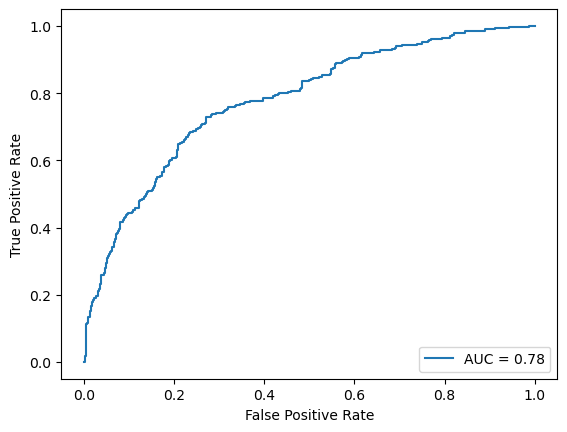

In [18]:
test_performances=torch.load("./test_savings/interaction_emb_concatenation_only/test_performances.pt",weights_only=False)
targets=test_performances["targets"]
log_probs=test_performances["log_probs"]
pos_probs=log_probs[:,1]
fpr, tpr, thresholds=roc_curve(y_true=targets,y_score=pos_probs)
roc_auc=roc_auc_score(y_true=targets,y_score=pos_probs)
print(f"The ROC AUC score is {roc_auc}")
display=RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc)
display.plot()
plt.show()


The meme is :


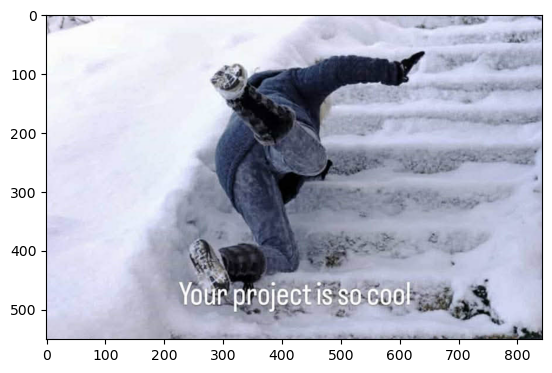

---------------------------
The text of the meme is :
'Your project is so cool'
---------------------------
Classification: The meme is lovely


In [19]:
#Detection for the concat without clip model
meme_image_path="..\meme.jpg"
meme_text="Your project is so cool"

meme_detector=MemeDetector(meme_image_path,meme_text,tokenizer,model,with_clip_image=False,with_clip_text=False)
meme_detector.detection()

## Test for the concat with clip model

In [21]:
#Testing run for the concat with clip model
path="./test_savings/interaction_emb_concatenation_with_clip"
model=DistilbertResnetModel(distilbert_model,resnet_model,with_clip_image=True,with_clip_text=True,concat_interaction=True,dropout=0.3,fc_layer_sizes=[640])
model_parameters=torch.load("single_train_savings/interaction_emb_concatenation_with_clip/model_state.pt")
model.load_state_dict(model_parameters)
loss_fn=CrossEntropyLoss(weight=class_weight)
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))
tester=Test(model,device,loss_fn,with_clip_text=True,with_clip_images=True,concat=True)
f1,accuracy,final_loss,all_predictions,all_targets,log_probs=tester.run_testing(test_dataloader,path)

2026-05-03 12:01:48.940 | INFO     | modules.model.test:run_testing:40 - Testing run:
2026-05-03 12:04:27.813 | INFO     | modules.model.test:run_testing:87 - Test Loss = 0.5947152961183477
2026-05-03 12:04:27.817 | INFO     | modules.model.test:run_testing:88 - Test F1 Score = 0.6568737905127146
2026-05-03 12:04:27.817 | INFO     | modules.model.test:run_testing:89 - Test Accuracy: = 0.6505882352941177


The ROC AUC score is 0.766467137915476


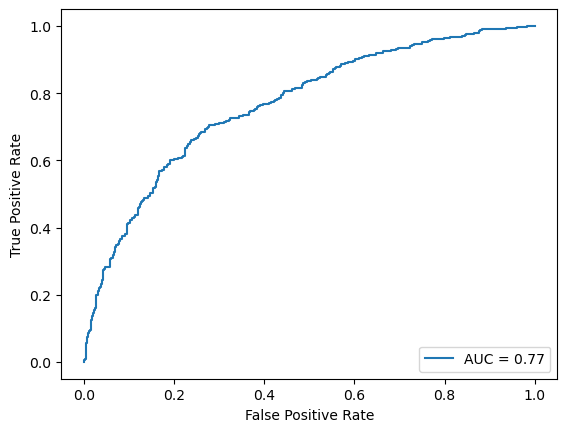

In [22]:
test_performances=torch.load("./test_savings/interaction_emb_concatenation_with_clip/test_performances.pt",weights_only=False)
targets=test_performances["targets"]
log_probs=test_performances["log_probs"]
pos_probs=log_probs[:,1]
fpr, tpr, thresholds=roc_curve(y_true=targets,y_score=pos_probs)
roc_auc=roc_auc_score(y_true=targets,y_score=pos_probs)
print(f"The ROC AUC score is {roc_auc}")
display=RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc)
display.plot()
plt.show()


The meme is :


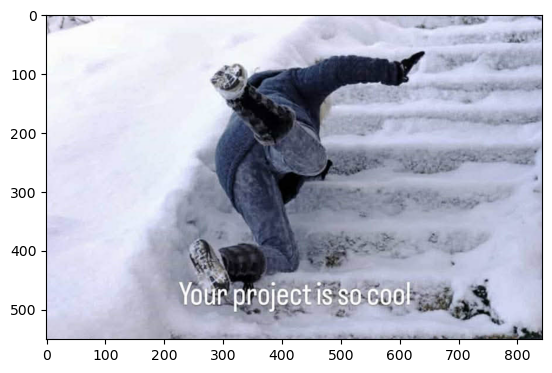

---------------------------
The text of the meme is :
'Your project is so cool'
---------------------------
Classification: The meme is lovely


In [23]:
#Detection for the concat with clip model
meme_image_path="..\meme.jpg"
meme_text="Your project is so cool"

meme_detector=MemeDetector(meme_image_path,meme_text,tokenizer,model,with_clip_image=True,with_clip_text=True,clip_model=clip_model,clip_processor=clip_processor)
meme_detector.detection()

## Test for the mean combination only model

In [24]:
#Testing run for the concat with clip model
path="./test_savings/mean_emb_combination_only"
model=DistilbertResnetModel(distilbert_model,resnet_model,with_clip_image=False,with_clip_text=False,concat_interaction=False,dropout=0.3,fc_layer_sizes=[384])
model_parameters=torch.load("single_train_savings/mean_emb_combination_only/model_state.pt")
model.load_state_dict(model_parameters)
loss_fn=CrossEntropyLoss(weight=class_weight)
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))
tester=Test(model,device,loss_fn,with_clip_text=False,with_clip_images=False,concat=False)
f1,accuracy,final_loss,all_predictions,all_targets,log_probs=tester.run_testing(test_dataloader,path)

2026-05-03 12:07:18.535 | INFO     | modules.model.test:run_testing:40 - Testing run:
2026-05-03 12:09:28.090 | INFO     | modules.model.test:run_testing:87 - Test Loss = 0.6119106124948572
2026-05-03 12:09:28.093 | INFO     | modules.model.test:run_testing:88 - Test F1 Score = 0.6611448711716092
2026-05-03 12:09:28.096 | INFO     | modules.model.test:run_testing:89 - Test Accuracy: = 0.6541176470588236


The ROC AUC score is 0.7314122424424725


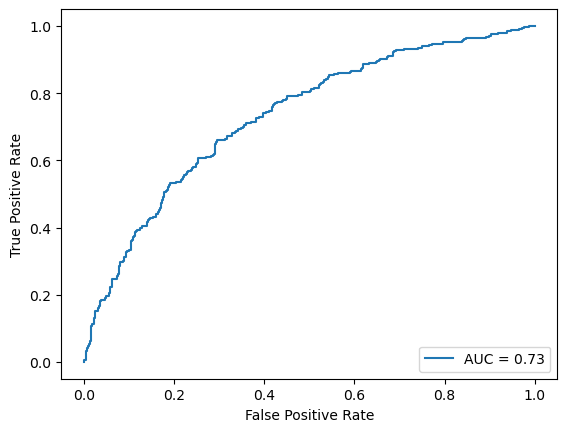

In [25]:
test_performances=torch.load("./test_savings/mean_emb_combination_only/test_performances.pt",weights_only=False)
targets=test_performances["targets"]
log_probs=test_performances["log_probs"]
pos_probs=log_probs[:,1]
fpr, tpr, thresholds=roc_curve(y_true=targets,y_score=pos_probs)
roc_auc=roc_auc_score(y_true=targets,y_score=pos_probs)
print(f"The ROC AUC score is {roc_auc}")
display=RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc)
display.plot()
plt.show()


The meme is :


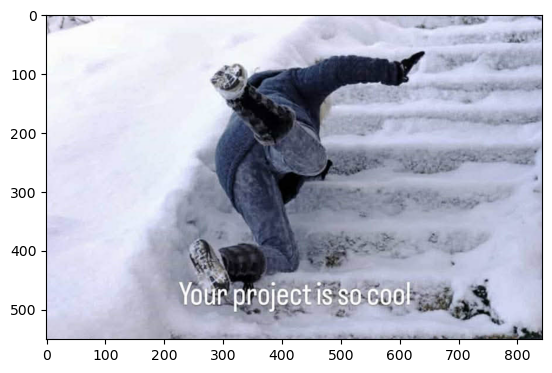

---------------------------
The text of the meme is :
'Your project is so cool'
---------------------------
Classification: The meme is lovely


In [26]:
#Detection for the concat with clip model
meme_image_path="..\meme.jpg"
meme_text="Your project is so cool"

meme_detector=MemeDetector(meme_image_path,meme_text,tokenizer,model,with_clip_image=False,with_clip_text=False,clip_model=clip_model,clip_processor=clip_processor)
meme_detector.detection()

## Test for the mean combination with clip model

In [27]:
#Testing run for the concat with clip model
path="./test_savings/mean_emb_combination_with_clip"
model=DistilbertResnetModel(distilbert_model,resnet_model,with_clip_image=True,with_clip_text=True,concat_interaction=False,dropout=0.3,fc_layer_sizes=[640])
model_parameters=torch.load("single_train_savings/mean_emb_combination_with_clip/model_state.pt")
model.load_state_dict(model_parameters)
loss_fn=CrossEntropyLoss(weight=class_weight)
device = (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu"))
tester=Test(model,device,loss_fn,with_clip_text=True,with_clip_images=True,concat=False)
f1,accuracy,final_loss,all_predictions,all_targets,log_probs=tester.run_testing(test_dataloader,path)

2026-05-03 12:10:15.611 | INFO     | modules.model.test:run_testing:40 - Testing run:
2026-05-03 12:12:47.462 | INFO     | modules.model.test:run_testing:87 - Test Loss = 0.5833243440698694
2026-05-03 12:12:47.463 | INFO     | modules.model.test:run_testing:88 - Test F1 Score = 0.6830525823581884
2026-05-03 12:12:47.464 | INFO     | modules.model.test:run_testing:89 - Test Accuracy: = 0.6764705882352942


The ROC AUC score is 0.7685486539329223


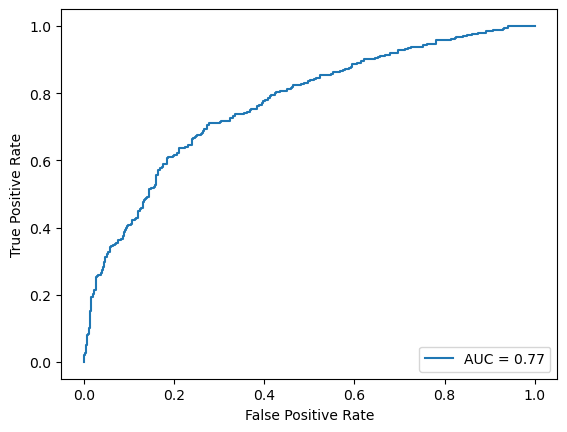

In [28]:
test_performances=torch.load("./test_savings/mean_emb_combination_with_clip/test_performances.pt",weights_only=False)
targets=test_performances["targets"]
log_probs=test_performances["log_probs"]
pos_probs=log_probs[:,1]
fpr, tpr, thresholds=roc_curve(y_true=targets,y_score=pos_probs)
roc_auc=roc_auc_score(y_true=targets,y_score=pos_probs)
print(f"The ROC AUC score is {roc_auc}")
display=RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc)
display.plot()
plt.show()


The meme is :


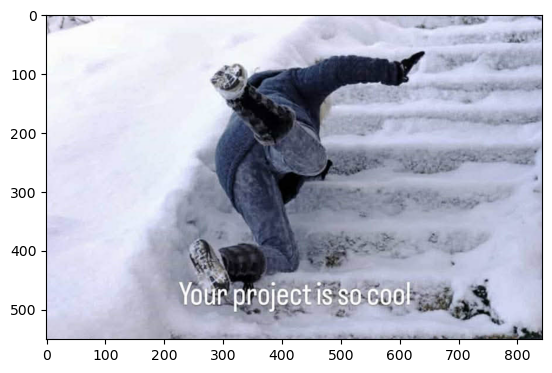

---------------------------
The text of the meme is :
'Your project is so cool'
---------------------------
Classification: The meme is lovely


In [29]:
#Detection for the concat with clip model
meme_image_path="..\meme.jpg"
meme_text="Your project is so cool"

meme_detector=MemeDetector(meme_image_path,meme_text,tokenizer,model,with_clip_image=True,with_clip_text=True,clip_model=clip_model,clip_processor=clip_processor)
meme_detector.detection()

## Optuna Study

In [7]:
#Training of the model using only concat interactions without clip embeddings
mlflow.set_tracking_uri("file:./mlflow_runs/interaction_emb_concatenation_only/mlruns")
mlflow.set_experiment("interaction_emb_concatenation_only")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///content/drive/MyDrive/Detection-of-Hateful-Memes-project/RESNET_BERT_model/mlflow_runs/interaction_emb_concatenation_only/mlruns/765048617505471002', creation_time=1777584717317, experiment_id='765048617505471002', last_update_time=1777584717317, lifecycle_stage='active', name='interaction_emb_concatenation_only', tags={}, trace_location=None, workspace='default'>

In [8]:
#Training of the model using only concat interactions without clip embeddings

mode="interaction_emb_concatenation_only"

hyperparameters_ranges={
    "batch_size":[32,64],
    "dropout":{
        "low":0.1,
        "high":0.5,
        "step":0.1
    },
    "dropout_ca":{
        "low":0.05,
        "high":0.3,
        "step":0.05
    },
    "lr":{
        "low":1e-4,
        "high":1e-2,
        "log":True
    },
    "weight_decay":{
        "low":1e-5,
        "high":1e-3,
        "log":True
    },
    "warmup_prop":{
        "low":0.01,
        "high":0.1,
        "step":0.01
    },
    "use_n_layers":{
        "low":1,
        "high":1,
        "step":1
    }

}

concat_interaction=True
simple_concat=False
with_clip_image=False
with_clip_text=False

device=torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
tokenizer=AutoTokenizer.from_pretrained("distilbert-base-uncased")
resnet_model=resnet_model=resnet18(weights=ResNet18_Weights.DEFAULT)
distilbert_model=DistilBertModel.from_pretrained("distilbert-base-uncased")
class_weight=compute_class_weight("balanced",classes=np.unique(train_df["label"]),y=train_df["label"].to_numpy())
class_weight=torch.tensor(class_weight,dtype=torch.float32,device=device)
loss_fn=CrossEntropyLoss(weight=class_weight)
n_epochs=10

optuna_obj=OptunaFunction(
    mode=mode,
    train_df=train_df,
    val_df=val_df,
    tokenizer=tokenizer,
    device=device,
    resnet_model=resnet_model,
    distilbert_model=distilbert_model,
    hyperparemeters_ranges=hyperparameters_ranges,
    loss_fn=loss_fn,
    with_clip_image=with_clip_image,
    with_clip_text=with_clip_text,
    concat_interaction=concat_interaction,
    simple_concat=simple_concat,
    n_epochs=n_epochs
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
if os.path.exists("./optuna_studies/interaction_emb_concatenation_only_study.db"):
    os.remove("./optuna_studies/interaction_emb_concatenation_only_study.db")
study=optuna.create_study(direction="maximize",pruner=optuna.pruners.MedianPruner(),storage="sqlite:///optuna_studies/interaction_emb_concatenation_only_study.db",load_if_exists=False,study_name="interaction_emb_concatenation_only_study")

[I 2026-04-30 22:17:27,346] A new study created in RDB with name: interaction_emb_concatenation_only_study


In [ ]:
study.optimize(optuna_obj.objective,n_trials=10)

## API

In [1]:
import requests
import json

In [12]:
url="http://127.0.0.1:8000/detection"
meme_image=open(r"C:\Users\sh032\OneDrive - HEC Montréal\Documents\Master 1\Detection-of-Hateful-Memes-project\meme.jpg","rb")
meme_text="Your project is so cool"

data={
    "meme_text":meme_text,
}

files={
    "meme_image":meme_image
}

response=requests.post(url,data=data,files=files)

In [13]:
print(response)

<Response [200]>


In [14]:
response.json()

{'label': 0, 'meaning': 'Classification: The meme is lovely'}

In [4]:
import pandas

In [5]:
print(pandas.__version__)

1.5.3


In [16]:
url="http://hm-detection-lb-425155408.us-east-1.elb.amazonaws.com/detection"
meme_image=open(r"C:\Users\sh032\OneDrive - HEC Montréal\Documents\Master 1\Detection-of-Hateful-Memes-project\meme.jpg","rb")
meme_text="Your project is so cool"

data={
    "meme_text":meme_text,
}

files={
    "meme_image":meme_image
}

response=requests.post(url,data=data,files=files)